
📌 Weight Distribution (EWM):
events.goals: 0.0599
events.assists: 0.0751
events.shots_on_target: 0.0407
events.key_passes: 0.0405
events.penalties_earned: 0.3652
touches.successful_passes: 0.3652
touches.take_on_successful: 0.0534

🌲 Weight Distribution (Random Forest):
events.goals: 0.0624
events.assists: 0.0117
events.shots_on_target: 0.3472
events.key_passes: 0.5026
events.penalties_earned: 0.0000
touches.successful_passes: 0.0000
touches.take_on_successful: 0.0762

⚡ Weight Distribution (XGBoost):
events.goals: 0.1062
events.assists: 0.0182
events.shots_on_target: 0.2154
events.key_passes: 0.5692
events.penalties_earned: 0.0000
touches.successful_passes: 0.0000
touches.take_on_successful: 0.0910

🔍 Spectral Clustering Result (Position: FW)
                  name           team_name  Cluster
          Asamoah Gyan NorthEast United FC        1
  Deshorn Dwayne Brown        Bengaluru FC        1
        Amine Chermiti      Mumbai City FC        2
   Thongkhosiem Haokip        Bengalu

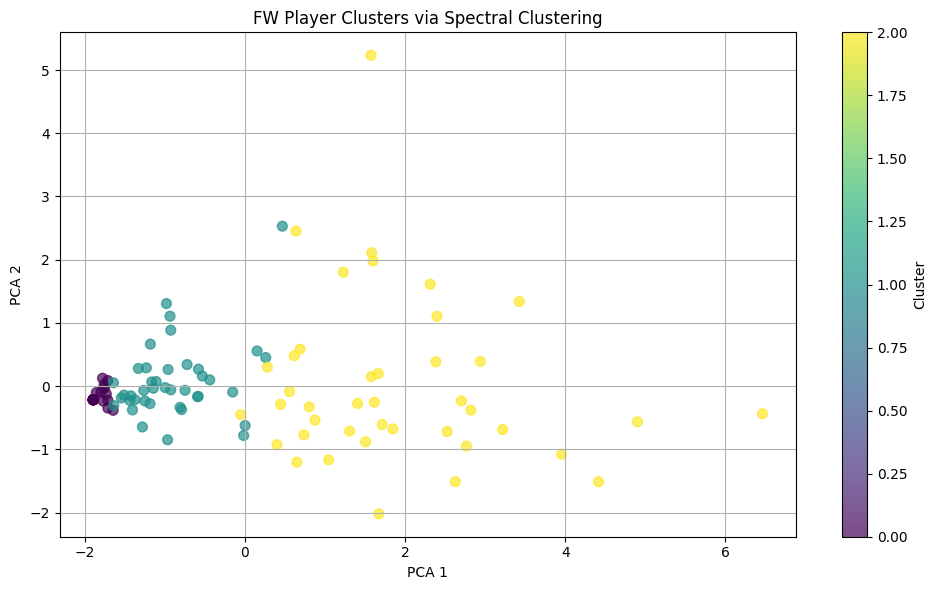


🏆 Top 10 Players (EWM) for Position: FW

                           name           team_name  Score_EWM
                    Roy Krishna     ATK Mohun Bagan   4.690444
Luis Miguel Vieira Babo Machado NorthEast United FC   3.786728
              Bright Enobakhare      SC East Bengal   3.547171
      Ferran Corominas Telechea              FC Goa   3.352573
                Nerijus Valskis       Chennaiyin FC   3.334658
          Marcelo Leite Pereira        Hyderabad FC   3.237857
Diego Mauricio Machado de Brito           Odisha FC   3.176134
                  Jordan Murray  Kerala Blasters FC   3.058026
            Bartholomew Ogbeche  Kerala Blasters FC   3.009292
   Martin Nicolas Chaves Garcia NorthEast United FC   2.933946

🏆 Top 10 Players (Random Forest) for Position: FW

                           name           team_name  Score_RF
                    Roy Krishna     ATK Mohun Bagan 29.424821
Luis Miguel Vieira Babo Machado NorthEast United FC 23.420397
                  Jordan Mu

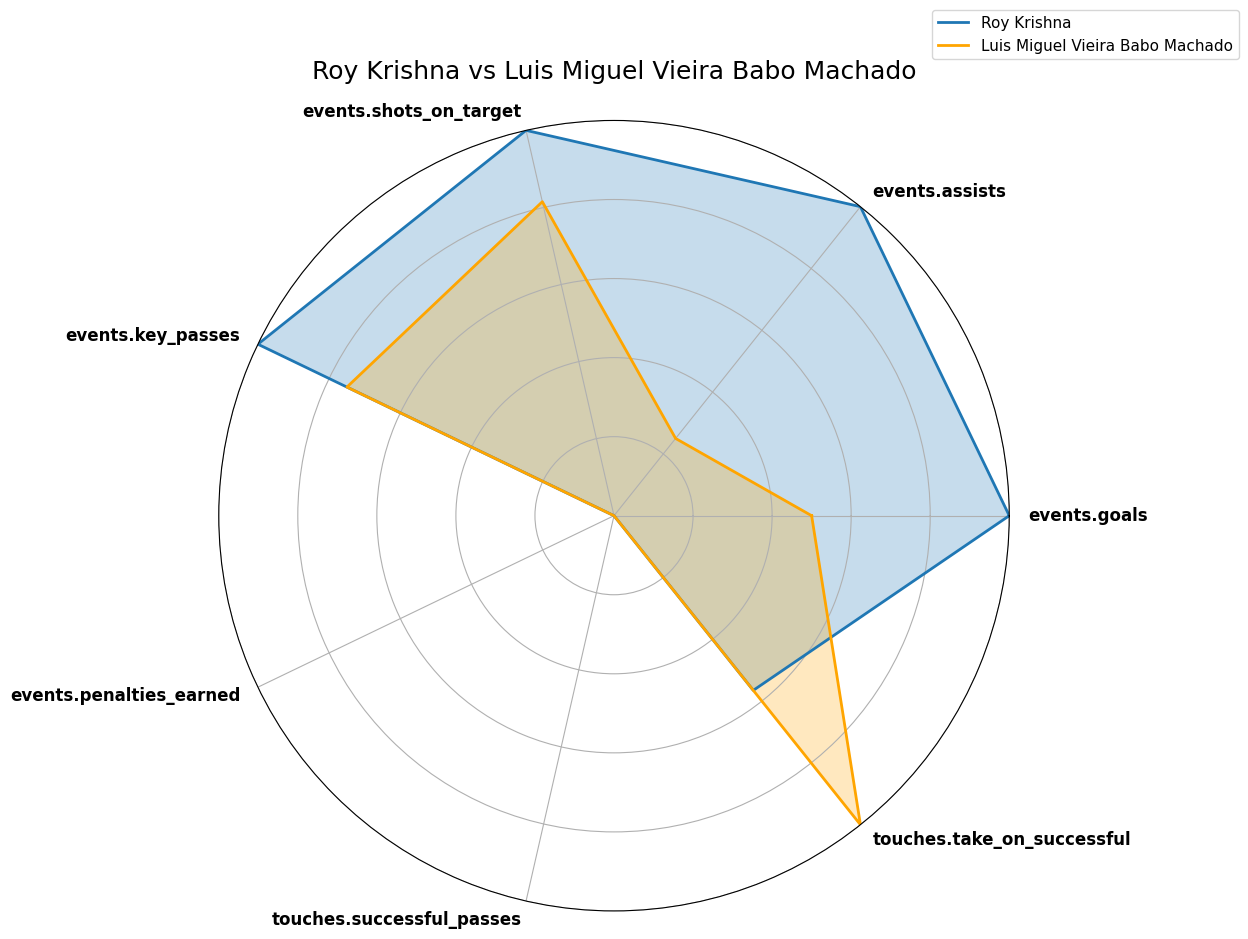


📊 Roy Krishna is in Cluster 2
📊 Luis Miguel Vieira Babo Machado is in Cluster 2
✅ Both players play with similar style.

🏆 Better Player (XGB): Roy Krishna (Score: 29.12)
🆚 Difference: 6.14


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi

from sklearn.cluster import SpectralClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor  # pip install xgboost


# =========================
# 1. Load and Clean Data
# =========================
def load_data(file_path):
    df = pd.read_csv(file_path)

    # Clean column names
    df.columns = df.columns.str.strip().str.replace('\ufeff', '')

    # Clean basic string columns
    df['name'] = df['name'].astype(str).str.strip()
    df['team_name'] = df['team_name'].astype(str).str.strip()
    df['position_short'] = df['position_short'].astype(str).str.upper().str.strip()

    # Normalize positions
    df['position_short'] = df['position_short'].replace({
        'F': 'FW', 'FWD': 'FW', 'ST': 'FW',
        'M': 'MF', 'MID': 'MF',
        'D': 'DF', 'DEF': 'DF',
        'GK': 'GK', 'G': 'GK'
    })

    # Handle missing values
    df.fillna(0, inplace=True)
    return df


# =========================
# 2. Radar Chart Plotting
# =========================
def plot_radar(player1_stats, player2_stats, stats_labels, player1, player2):
    angles = [n / float(len(stats_labels)) * 2 * pi for n in range(len(stats_labels))]
    angles += angles[:1]

    # Close the loop for radar chart
    player1_stats = np.append(player1_stats, player1_stats[0])
    player2_stats = np.append(player2_stats, player2_stats[0])

    fig, ax = plt.subplots(figsize=(12, 10), subplot_kw=dict(polar=True))

    # Player 1
    ax.plot(angles, player1_stats, linewidth=2, linestyle='solid', label=player1)
    ax.fill(angles, player1_stats, alpha=0.25)

    # Player 2
    ax.plot(angles, player2_stats, linewidth=2, linestyle='solid', label=player2, color='orange')
    ax.fill(angles, player2_stats, alpha=0.25, color='orange')

    # Stat labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(stats_labels, fontsize=12, fontweight='bold')

    # Rotate labels
    for label, angle in zip(ax.get_xticklabels(), angles):
        angle_deg = np.degrees(angle)
        if 90 <= angle_deg <= 270:
            label.set_rotation(angle_deg + 180)
            label.set_verticalalignment('center')
            label.set_horizontalalignment('right')
        else:
            label.set_rotation(angle_deg)
            label.set_verticalalignment('center')
            label.set_horizontalalignment('left')
        label.set_rotation_mode('anchor')

    ax.set_rlabel_position(0)
    ax.set_yticklabels([])
    ax.set_ylim(0, 1)

    ax.set_title(f"{player1} vs {player2}", size=18, pad=30)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15), fontsize=11)
    plt.tight_layout(pad=3.0)
    plt.show()


# =========================
# 3. Weight Computation Helpers
# =========================

def compute_ewm_weights(X: pd.DataFrame) -> np.ndarray:
    """
    Entropy Weight Method (unsupervised).
    X: DataFrame of stats (players x features)
    """
    data = X.astype(float).values
    # Column-wise normalization
    col_sums = np.maximum(data.sum(axis=0), 1e-12)
    P = data / col_sums

    n = P.shape[0]
    if n <= 1:
        # Degenerate case: only one player; give equal weights
        return np.ones(P.shape[1]) / P.shape[1]

    k = 1 / np.log(n)

    # Entropy per feature
    entropy = -k * np.nansum(P * np.log(P + 1e-12), axis=0)

    # Divergence (importance)
    divergence = 1 - entropy
    # Avoid division by zero
    if divergence.sum() == 0:
        return np.ones_like(divergence) / len(divergence)

    weights = divergence / divergence.sum()
    return weights


def compute_rf_weights(X: pd.DataFrame) -> np.ndarray:
    """
    Random Forest feature importances as weights (supervised).
    Target y = sum of stats (proxy performance).
    """
    X_numeric = X.astype(float)
    y = X_numeric.sum(axis=1)

    rf = RandomForestRegressor(n_estimators=300, random_state=42)
    rf.fit(X_numeric, y)

    importances = rf.feature_importances_
    if importances.sum() == 0:
        return np.ones_like(importances) / len(importances)

    weights = importances / importances.sum()
    return weights


def compute_xgb_weights(X: pd.DataFrame) -> np.ndarray:
    """
    XGBoost feature importances as weights (supervised).
    Target y = sum of stats (proxy performance).
    """
    X_numeric = X.astype(float)
    y = X_numeric.sum(axis=1)

    xgb_model = XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective='reg:squarederror'
    )
    xgb_model.fit(X_numeric, y)

    importances = xgb_model.feature_importances_
    if importances.sum() == 0:
        return np.ones_like(importances) / len(importances)

    weights = importances / importances.sum()
    return weights


# =========================
# 4. Main Script
# =========================
def main():
    # ---- Load dataset ----
    file_path = r"/Users/aranyabasu/Desktop/dataanalysislearning/Project_Final/source_code/final_year_project_dataset.csv"  # change if needed
    df = load_data(file_path)

    # ---- Step 1: Ask for Position ----
    position_input = input("Enter position (FW, MF, DF, GK): ").strip().upper()
    valid_positions = ['FW', 'MF', 'DF', 'GK']
    if position_input not in valid_positions:
        raise ValueError("Invalid position entered.")

    # ---- Step 2: Define stats ----
    if position_input == 'FW':
        stats = [
            'events.goals', 'events.assists', 'events.shots_on_target', 'events.key_passes',
            'events.penalties_earned', 'touches.successful_passes', 'touches.take_on_successful'
        ]
    elif position_input == 'MF':
        stats = [
            'events.assists', 'events.key_passes', 'events.chances_created',
            'touches.successful_passes', 'touches.interceptions', 'events.goals'
        ]
    elif position_input == 'DF':
        stats = [
            'touches.tackles', 'touches.blocks', 'touches.interceptions',
            'touches.clearance', 'events.cleansheet', 'touches.successful_passes'
        ]
    elif position_input == 'GK':
        stats = [
            'goaltenders.saves', 'goaltenders.shots_faced', 'events.cleansheet',
            'goaltenders.penalty_kicks.saves', 'goaltenders.goals_allowed'
        ]

    # ---- Filter to selected position ----
    position_df = df[df['position_short'] == position_input].copy()

    # Make sure selected stats exist and are numeric
    for col in stats:
        if col not in position_df.columns:
            raise KeyError(f"Stat column '{col}' not found in dataset.")

    X = position_df[stats].astype(float)

    # Optional: transform "bad" stats (e.g., for GK) so that higher = better
    if position_input == 'GK':
        X['goaltenders.goals_allowed'] = -X['goaltenders.goals_allowed']
        X['goaltenders.shots_faced'] = -X['goaltenders.shots_faced']

    # =========================
    # Step 3: Compute Weights (EWM, RF, XGB)
    # =========================

    # --- EWM ---
    weights_ewm = compute_ewm_weights(X)
    print("\n📌 Weight Distribution (EWM):")
    for s, w in zip(stats, weights_ewm):
        print(f"{s}: {w:.4f}")
    position_df['Score_EWM'] = X.dot(weights_ewm)

    # --- Random Forest ---
    weights_rf = compute_rf_weights(X)
    print("\n🌲 Weight Distribution (Random Forest):")
    for s, w in zip(stats, weights_rf):
        print(f"{s}: {w:.4f}")
    position_df['Score_RF'] = X.dot(weights_rf)

    # --- XGBoost ---
    weights_xgb = compute_xgb_weights(X)
    print("\n⚡ Weight Distribution (XGBoost):")
    for s, w in zip(stats, weights_xgb):
        print(f"{s}: {w:.4f}")
    position_df['Score_XGB'] = X.dot(weights_xgb)

    # =========================
    # Step 4: Spectral Clustering
    # =========================
    features = X  # already numeric
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(features)

    n_clusters = 3
    spectral = SpectralClustering(
        n_clusters=n_clusters,
        affinity='nearest_neighbors',
        random_state=42
    )
    position_df['Cluster'] = spectral.fit_predict(scaled_features)

    print(f"\n🔍 Spectral Clustering Result (Position: {position_input})")
    print(position_df[['name', 'team_name', 'Cluster']].head(10).to_string(index=False))

    # =========================
    # Step 5: PCA Visualization
    # =========================
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(scaled_features)

    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(
        pca_result[:, 0],
        pca_result[:, 1],
        c=position_df['Cluster'],
        cmap='viridis',
        s=50,
        alpha=0.7
    )
    plt.title(f'{position_input} Player Clusters via Spectral Clustering')
    plt.xlabel('PCA 1')
    plt.ylabel('PCA 2')
    plt.colorbar(scatter, label='Cluster')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # =========================
    # Step 6: Top 10 Players for Each Method
    # =========================
    def get_top10(score_col):
        top_players = position_df.sort_values(by=score_col, ascending=False) \
                                 .drop_duplicates(subset='name', keep='first')
        return top_players[['name', 'team_name', score_col]].head(10), top_players

    top10_ewm, top_players_ewm = get_top10('Score_EWM')
    top10_rf, top_players_rf = get_top10('Score_RF')
    top10_xgb, top_players_xgb = get_top10('Score_XGB')

    print(f"\n🏆 Top 10 Players (EWM) for Position: {position_input}\n")
    print(top10_ewm.to_string(index=False))

    print(f"\n🏆 Top 10 Players (Random Forest) for Position: {position_input}\n")
    print(top10_rf.to_string(index=False))

    print(f"\n🏆 Top 10 Players (XGBoost) for Position: {position_input}\n")
    print(top10_xgb.to_string(index=False))

    # =========================
    # Step 7: Combined Comparison Table (Ranks under all 3 methods)
    # =========================
    # Use per-player max score for each method
    agg_df = position_df.groupby(['name', 'team_name'], as_index=False).agg({
        'Score_EWM': 'max',
        'Score_RF': 'max',
        'Score_XGB': 'max'
    })

    # Compute ranks (1 = best) for each method
    agg_df['Rank_EWM'] = agg_df['Score_EWM'].rank(ascending=False, method='min').astype(int)
    agg_df['Rank_RF'] = agg_df['Score_RF'].rank(ascending=False, method='min').astype(int)
    agg_df['Rank_XGB'] = agg_df['Score_XGB'].rank(ascending=False, method='min').astype(int)

    # Optional: average rank to sort
    agg_df['Avg_Rank'] = agg_df[['Rank_EWM', 'Rank_RF', 'Rank_XGB']].mean(axis=1)

    # Sort by average rank (best overall first)
    combined_rank_table = agg_df.sort_values(by='Avg_Rank')

    print("\n📊 Combined Ranking Comparison (all methods):")
    print(combined_rank_table[['name', 'team_name',
                               'Score_EWM', 'Rank_EWM',
                               'Score_RF', 'Rank_RF',
                               'Score_XGB', 'Rank_XGB',
                               'Avg_Rank']].head(20).to_string(index=False))

    # (You can also export this to CSV if you want)
    # combined_rank_table.to_csv("combined_rank_table_{}.csv".format(position_input), index=False)

    # =========================
    # Step 8: Choose Method for Comparison
    # =========================
    method_input = input("\nChoose ranking method for comparison (EWM, RF, XGB): ").strip().upper()
    if method_input not in ['EWM', 'RF', 'XGB']:
        print("Invalid method entered, defaulting to RF.")
        method_input = 'RF'

    if method_input == 'EWM':
        chosen_score_col = 'Score_EWM'
        chosen_top_players = top_players_ewm
        chosen_top10 = top10_ewm
    elif method_input == 'RF':
        chosen_score_col = 'Score_RF'
        chosen_top_players = top_players_rf
        chosen_top10 = top10_rf
    else:  # XGB
        chosen_score_col = 'Score_XGB'
        chosen_top_players = top_players_xgb
        chosen_top10 = top10_xgb

    print(f"\nUsing {method_input} ranking. Top 10 list:\n")
    print(chosen_top10.to_string(index=False))

    # =========================
    # Step 9: Select two players for Comparison
    # =========================
    player1 = input("\nEnter first player name from above list: ").strip()
    player2 = input("Enter second player name from above list: ").strip()

    if player1.lower() == player2.lower():
        raise ValueError("Players must be different.")

    def get_player_row(df_players, name):
        mask = df_players['name'].str.lower() == name.lower()
        return df_players[mask]

    row1 = get_player_row(chosen_top_players, player1)
    row2 = get_player_row(chosen_top_players, player2)

    if row1.empty or row2.empty:
        raise ValueError("Invalid player names entered (must be from the chosen Top 10 list).")

    values1 = row1.iloc[0][stats].values.astype(float)
    values2 = row2.iloc[0][stats].values.astype(float)

    # =========================
    # Step 10: Normalize for Radar Chart
    # =========================
    max_vals = np.maximum(values1, values2)
    values1_norm = np.divide(values1, max_vals, out=np.zeros_like(values1), where=max_vals != 0)
    values2_norm = np.divide(values2, max_vals, out=np.zeros_like(values2), where=max_vals != 0)

    plot_radar(values1_norm, values2_norm, stats, row1.iloc[0]['name'], row2.iloc[0]['name'])

    # =========================
    # Step 11: Display Cluster & Score Info
    # =========================
    score1 = float(row1[chosen_score_col].values[0])
    score2 = float(row2[chosen_score_col].values[0])
    diff = abs(score1 - score2)

    cluster1 = int(row1['Cluster'].values[0])
    cluster2 = int(row2['Cluster'].values[0])

    print(f"\n📊 {row1.iloc[0]['name']} is in Cluster {cluster1}")
    print(f"📊 {row2.iloc[0]['name']} is in Cluster {cluster2}")

    if cluster1 == cluster2:
        print("✅ Both players play with similar style.")
    else:
        print("⚠️ Players have different playing styles.")

    if score1 > score2:
        print(f"\n🏆 Better Player ({method_input}): {row1.iloc[0]['name']} (Score: {score1:.2f})")
        print(f"🆚 Difference: {diff:.2f}")
    elif score2 > score1:
        print(f"\n🏆 Better Player ({method_input}): {row2.iloc[0]['name']} (Score: {score2:.2f})")
        print(f"🆚 Difference: {diff:.2f}")
    else:
        print(f"\n🤝 Both are equally strong ({method_input})! Score: {score1:.2f}")


if __name__ == "__main__":
    main()


Combined Player Ranking Using Multiple Weighting Techniques

Player performance in football is influenced by a wide variety of situational and role-specific metrics. To generate robust rankings and reduce method-specific bias, our model evaluates players using three complementary scoring techniques:

Entropy Weight Method (EWM)

A purely data-driven and unsupervised method.

Attributes that vary more across players receive higher weights, emphasizing statistics that better distinguish performance differences.

Random Forest Feature Importance

A supervised ensemble learning-based weighting.

Uses a proxy performance target (sum of stats) and learns which metrics contribute most to overall performance variation.

XGBoost Feature Importance

A boosted decision tree-based weighting method.

Captures non-linear interactions between performance metrics and models incremental gains in prediction accuracy.

Each technique produces a separate ranking list based on its own statistical perspective. To arrive at a more comprehensive and stable evaluation, individual player ranks from all three methods are combined into a Consolidated Ranking Table:

Maximum score per player is taken from multiple appearances in the dataset.

Ranks are calculated for each scoring method (1 = best).

An Average Rank is computed and used to generate a final unified leaderboard.

This combined-ranking approach reduces reliance on any single statistical assumption and allows more reliable cross-method validation of player performance.